In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
url = r"C:\Users\vedba\Documents\DSBDAL_prac\StudentsPerformance.csv"
df=pd.read_csv(url)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.dtypes
df.describe()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


(1000, 8)

In [6]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
def handle_outliers(col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[col]<lower)|(df[col]>upper)]
    print(outliers[col])


for col in ['math score', 'reading score', 'writing score']:
    handle_outliers(col)

17     18
59      0
145    22
338    24
466    26
787    19
842    23
980     8
Name: math score, dtype: int64
59     17
76     26
211    28
327    23
596    24
980    24
Name: reading score, dtype: int64
59     10
76     22
327    19
596    15
980    23
Name: writing score, dtype: int64


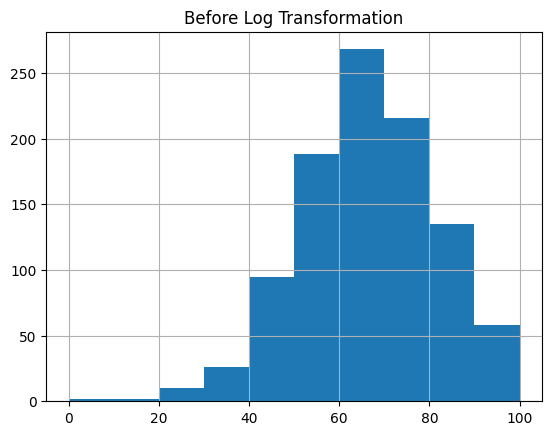

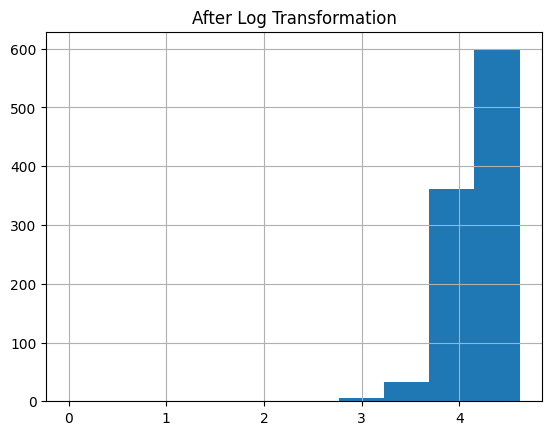

,math score,reading score,writing score,math_log
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,4.174093
std,15.16308,14.600192,15.195657,0.284629
min,0.00000,17.000000,10.000000,0.000000
25%,57.00000,59.000000,57.750000,4.060443
50%,66.00000,70.000000,69.000000,4.204693
75%,77.00000,79.000000,79.000000,4.356709
max,100.00000,100.000000,100.000000,4.615121


In [9]:
import matplotlib.pyplot as plt
# Before transformation
df['math score'].hist()
plt.title("Before Log Transformation")
plt.show()

# Apply log transformation
df['math_log'] = np.log1p(df['math score'])

# After transformation
df['math_log'].hist()
plt.title("After Log Transformation")
plt.show()
df.describe()

In [10]:
# Apply scaling (0 to 1)
df['math_scaled'] = (df['math score'] - df['math score'].min()) / (df['math score'].max() - df['math score'].min())

# Check result
print(df[['math score', 'math_scaled']].head())

   math score  math_scaled
0          72         0.72
1          69         0.69
2          90         0.90
3          47         0.47
4          76         0.76
